# Index Calculations with Python

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nrevyw/wyvern-public-resources/blob/main/tutorial-notebooks/index-calculation/index_calculation.ipynb)

Calculating indices like NDVI or NDWI is an extremely common task in geospatial analysis.
Many tools like QGIS provide a user-friendly interface for calculating indices; with Python we have to do more of the hard work ourselves.
Using a more programmatic interface for these analyses lets us start to build data pipelines and scale our data solutions.

Index calculations, in their simplest form, is just math applied to arrays of numbers (raster images!).
There are a number of packages available in Python for working with arrays. We'll cover the most popular (Numpy) here.

This tutorial will use this image over southern Alberta, available for download at our [Open Data Program](https://opendata.wyvern.space/#/year/2025/wyvern_dragonette-004_20251005T172442_932fa466_l2a/wyvern_dragonette-004_20251005T172442_932fa466_l2a.json).

## Getting Started
- **Google Colab (easiest):** open this notebook using the "Open in Colab" badge above, then run the cells top to bottom.
- **Local Jupyter:** run this notebook in your tool of choice (Jupyter Lab, Visual Studio Code, etc). The Setup cell below installs everything needed, no environment to build ahead of time. 

In [1]:
# Install the packages this notebook needs.
%pip install -q numpy matplotlib requests rasterio

Note: you may need to restart the kernel to use updated packages.


## High Level Workflow
1. Load in our raster data using [Rasterio](https://rasterio.readthedocs.io/en/stable/).
2. Create a dictionary the band wavelengths and their corresponding index in the raster.
3. Calculate our indices using [Numpy](https://numpy.org/).

First let's import all the packages we'll need.

In [2]:
import rasterio
import numpy as np
import json
import matplotlib.pyplot as plt

## Download the Tutorial Files

Let's download the files we'll be working with for this tutorial!

We'll be using a hyperspectral GeoTIFF image over southern Alberta and a STAC JSON metadata file. The GeoTIFF contains the image data, and the STAC JSON gives us useful metadata about the scene.

Run the cell below to download these files. Once the download is complete, they'll appear in the same folder as your notebook!

In [3]:
import requests
from pathlib import Path

IMAGE_URL = "https://wyvern-data.com/wyvern_dragonette-004_20251005T172442_932fa466_l2a/wyvern_dragonette-004_20251005T172442_932fa466_l2a.tiff"
JSON_URL = "https://wyvern-odp.com/wyvern_dragonette-004_20251005T172442_932fa466_l2a/wyvern_dragonette-004_20251005T172442_932fa466_l2a.json"

IMAGE_PATH = Path("wyvern_dragonette-004_20251005T172442_932fa466_l2a.tiff")
JSON_PATH = Path("wyvern_dragonette-004_20251005T172442_932fa466_l2a.json")

downloads = [
    (IMAGE_URL, IMAGE_PATH),
    (JSON_URL, JSON_PATH),
]

for url, path in downloads:
    if path.exists():
        print(f"{path.name} File already here! Skipping download.")
    else:
        print(f"Downloading {path.name}...")
        response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
        response.raise_for_status()
        path.write_bytes(response.content)

print("Downloads complete!")

Downloads complete!


### Loading the Data

We'll start by reading the scale factor from the metadata JSON file we downloaded earlier. Wyvern's L2A products represent surface reflectance, but the values are stored as scaled 16-bit integers to reduce file size.

We can grab the scale value we need from the metadata file. More documentation about processing levels can be found in our [documentation](https://guide.wyvern.space/data-product-guide/technical-specifications/processing-levels/#level-2a-surface-reflectance).

In [4]:
# Open the JSON metadata file and extract the scale factor
with open(JSON_PATH) as json_file:
    metadata_json = json.load(json_file)

scale_factor = metadata_json["assets"]["Cloud optimized GeoTiff"]["raster:bands"][0][
    "scale"
]

print(f"Scale factor: {scale_factor}")

Scale factor: 0.0001


Now let's open the GeoTIFF. We'll replace any nodata pixels (the provided uint16 maximum of `65535`) with `np.nan` so they are excluded from our calculations, then apply the scale factor to recover the floating-point reflectance values.

In [5]:
with rasterio.open(IMAGE_PATH) as image_file:
    # Convert to float so we can use np.nan and decimal values
    image_array = image_file.read().astype(float)
    nodata_value = image_file.nodata

# Arrange nodata values to be np.nan
if nodata_value is not None:
    image_array[image_array == nodata_value] = np.nan

# Scale data based on scale factor in metadata file
image_array = image_array * scale_factor

Now let's build a map from wavelength to band index using the `eo:bands` metadata, so we can select bands by wavelength rather than hardcoding band numbers.

This lets our code be more reusable across Wyvern scenes/sensors with different band configurations.

In [6]:
eo_bands = metadata_json["assets"]["Cloud optimized GeoTiff"]["eo:bands"]
wavelength_map = {}
for i, band in enumerate(eo_bands):
    wavelength = round(band["center_wavelength"] * 1000)  # convert from μm to nm
    wavelength_map[wavelength] = i

print(wavelength_map)

{444: 0, 464: 1, 480: 2, 490: 3, 503: 4, 510: 5, 520: 6, 535: 7, 549: 8, 569: 9, 584: 10, 600: 11, 615: 12, 634: 13, 650: 14, 659: 15, 669: 16, 680: 17, 690: 18, 699: 19, 711: 20, 722: 21, 735: 22, 750: 23, 765: 24, 782: 25, 799: 26, 815: 27, 832: 28, 850: 29, 870: 30}


### Selecting Bands by Wavelength

Now we'll write a small helper function that finds the nearest available band to any wavelength we ask for. This means if we request 550nm and the closest available band is actually 549nm, it'll find it automatically and tell us which band it used.

In [7]:
def get_band(wavelength_nm: int) -> np.ndarray:
    """
    Returns the image band closest to the requested wavelength.

    Args:
        wavelength_nm: Target wavelength in nanometres.

    Returns:
        A 2D array containing reflectance values for the closest available wavelength band.
    """
    available_wavelengths = list(wavelength_map.keys())
    closest_wavelength = min(
        available_wavelengths, key=lambda w: abs(w - wavelength_nm)
    )
    print(f"Requested {wavelength_nm}nm -- using {closest_wavelength}nm")
    return image_array[wavelength_map[closest_wavelength]]

Let's take a look at our image and confirm everything was read in correctly.

We'll use Matplotlib and plot an RGB rendering of our data.

Requested 650nm -- using 650nm
Requested 550nm -- using 549nm
Requested 480nm -- using 480nm


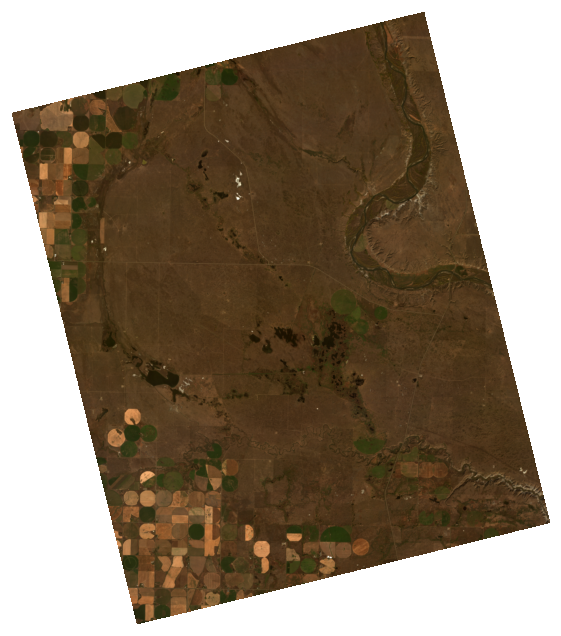

In [8]:
# Select our RGB bands by wavelength, then stack them into a [rows, columns, channels]
# array which matplotlib expects
rgb_arr = np.dstack([get_band(650), get_band(550), get_band(480)]).astype(np.float32)

brightness_factor = 3  # Bring up the brightness a touch so we have a better visual
rgb_arr_bright = rgb_arr * brightness_factor
rgb_arr_bright = np.clip(rgb_arr_bright, 0, 1)  # keep values within 0-1

plt.figure(figsize=(12, 8))
plt.imshow(rgb_arr_bright)
plt.axis("off")

plt.show()

That all looks great! Now we will move to actually compute the indices of use to us for our image. We will compute RENDVI and MTVI2.
The wavelengths selected are based off the data available in our hyperspectral library; feel free to explore for other indices you may be interested in!

Note that we're using `get_band()` here, so each of these is the *nearest available* Wyvern band to the nominal index wavelength, not necessarily an exact match. Keep an eye on the printed "Requested Xnm -- using Ynm" output to see how close each one lands.

In [9]:
# RENDVI
band_750 = get_band(750)
band_705 = get_band(705)

# MTVI2
band_550 = get_band(550)
band_670 = get_band(670)
band_800 = get_band(800)

# Compute our indices
rendvi_array = (band_750 - band_705) / (band_750 + band_705)
mtvi2 = 1.5 * (
    (1.2 * (band_800 - band_550) - 2.5 * (band_670 - band_550))
    / (
        np.sqrt(
            (2 * band_800 + 1) ** 2 - (6 * band_800) + (5 * np.sqrt(band_670)) - 0.5
        )
    )
)

Requested 750nm -- using 750nm
Requested 705nm -- using 699nm
Requested 550nm -- using 549nm
Requested 670nm -- using 669nm
Requested 800nm -- using 799nm


Now we can plot our RGB image alongside our freshly computed indices and see how they look.

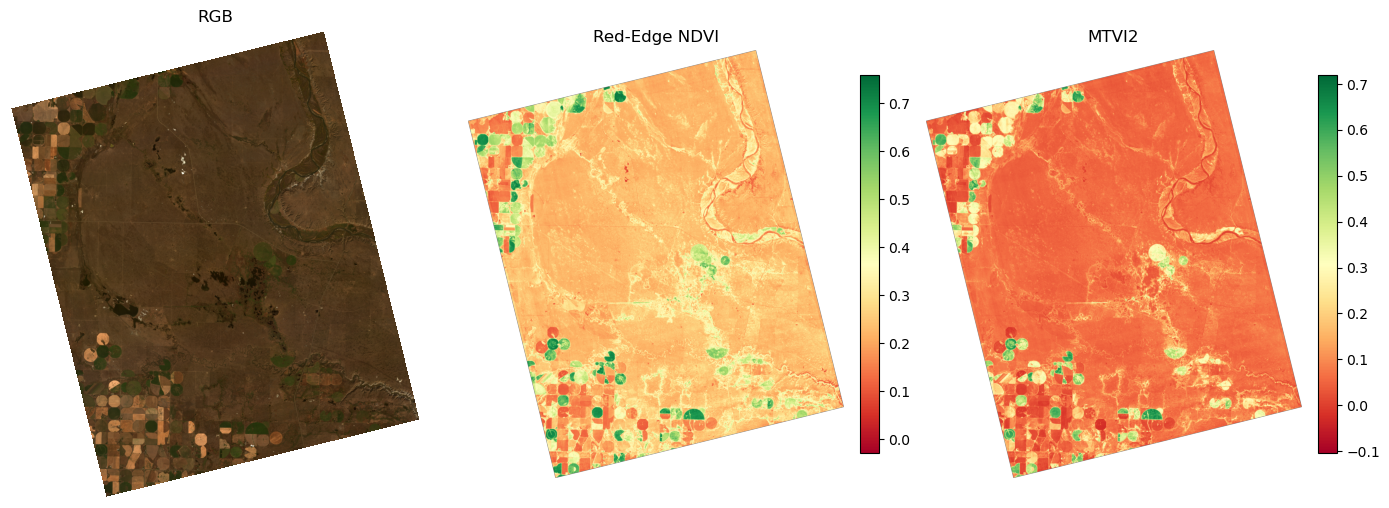

In [10]:
# Plot our bright RGB and two indices
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# Plot RGB image
im0 = axes[0].imshow(rgb_arr_bright)
axes[0].set_title("RGB")
axes[0].axis("off")

# Plot Red-Edge NDVI
im1 = axes[1].imshow(rendvi_array, cmap="RdYlGn")
axes[1].set_title("Red-Edge NDVI")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Plot MTVI2
im2 = axes[2].imshow(mtvi2, cmap="RdYlGn")
axes[2].set_title("MTVI2")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Those look great!

Hyperspectral imagery's advantage here is its much finer spectral sampling, which lets us select narrower, more precisely-placed bands than a typical multispectral or optical sensor usually offers.
Compared to RGB, both hyperspectral indices enhance biophysical signal over visual appearance.
RENDVI emphasizes chlorophyll-related spectral shifts in the red-edge region, whereas MTVI2 is designed to stay sensitive to green leaf area and canopy structure while reducing the influence of chlorophyll variation and soil background.
The differences in spatial patterns between the two indices demonstrate how band selection and mathematical formulation influence the type of vegetation information extracted from hyperspectral data.

Try building these indices on your own dataset and compare the results.
The more you experiment, the more you'll uncover.

## Other Packages

Many Python packages meant for remote sensing data will also include helpful functions for calculating indices. There also exists a wider ecosystem outside of Python for analysis of multispectral & hyperspectral data that is worth diving into!

### EarthPy
[EarthPy](https://earthpy.readthedocs.io/en/latest/api/earthpy.spatial.html#earthpy.spatial.normalized_diff) provides a useful `normalized_diff()` function, which can be used to calculate indices such as NDVI

### Xarray-Spatial
[Xarray-spatial has built in functions](https://xarray-spatial.org/user_guide/multispectral.html) for calculating a number of useful multispectral indices using Xarray arrays, including NDVI, SAVI, and True Color

### Awesome-Spectral-Indices
David Montero Loaiza's [Awesome Spectral Indices](https://github.com/awesome-spectral-indices/awesome-spectral-indices) project contains a number of packages in different languages for calculating multispectral indices. For the Python ecosystem, [Spyndex](https://github.com/awesome-spectral-indices/spyndex) is available for use. The advantage of this system is that a standard database of indices is pulled from, instead of having to form the equations yourself.